<a href="https://colab.research.google.com/github/santoshs0612/Foundational-Math-in-ML/blob/main/Adam_Gradient_decent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Adam Gragient decent and Batch Gradient decent

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Loss Function definition(we starting with any random loss function)

In [2]:
def quadratic_loss(x,y):
  return x**2 + 10 *y**2

### Gradient Function

In [3]:
def quadratic_grad(x ,y):
  dx = 2 *x
  dy = 20* y
  return np.array([dx,dy])

### Batch Gradient decent

In [4]:

def batch_grad_decent(grad_fun,eta, epochs,start_point):
  x ,y = start_point
  path = [(x,y)]
  losses = [quadratic_loss(x,y)]

  for _ in range(epochs):
    grad = grad_fun(x,y)
    x = x - eta * grad[0]
    y = y - eta * grad[1]
    path.append((x, y))
    losses.append(quadratic_loss(x,y))
  return np.array(path),losses

### Adam Optimizer

In [5]:
def adam_optimizer(grad_fun,lr,beta1,beta2,epsilon,epochs,start_point):
  x ,y = start_point
  m = np.array([0.0,0.0]) # First Moment(momentum)
  v = np.array([0.0,0.0]) # Second moment (RMSProp)
  path = [(x,y)]
  losses = [quadratic_loss(x,y)]
  for t in range(1, epochs+1):
    grad = grad_fun(x,y)
    # Update biased first moment estimate
    m = beta1 * m + (1-beta1) * grad
    # Update biased second moment
    v = beta2 * v + (1-beta2) * grad**2
    #bias correction
    m_hat = m / (1-beta1**t)
    v_hat = v / (1-beta2**t)
    # Update Parameter
    x = x - lr * m_hat[0] / (np.sqrt(v_hat[0]) + epsilon)
    y = y - lr * m_hat[1] / (np.sqrt(v_hat[1]) + epsilon)

    path.append((float(x), float(y)))
    losses.append(quadratic_loss(x,y))
  return np.array(path),losses



### Visualization of Paths

In [6]:
def plot_paths(function,paths,labels,title):
  X,Y = np.meshgrid(np.linspace(-2,2,400),np.linspace(-2,2,400))
  Z = function(X,Y)
  plt.figure(figsize=(8,6))
  plt.contour(X,Y,Z,levels=50,cmap='jet')

  for path,label in zip(paths,labels):
    plt.plot(path[:,0],path[:,1],label=label)
    plt.scatter(path[0,0],path[0,1],color='green',label ="Start")
    plt.scatter(path[-1,0],path[-1,1],color='red',label ="End")
  plt.title(title)
  plt.xlabel('x')
  plt.ylabel('y')
  plt.legend()
  plt.show()

### Visualization of losses

In [7]:
def plot_losses(losses,labels,title):
  plt.figure(figsize=(8,6))
  for loss,label in zip(losses,labels):
    plt.plot(loss,label=label)
  plt.title(title)
  plt.xlabel('Epochs')
  plt.ylabel('Loss')
  plt.legend()
  plt.show()

### Parameter Defination

In [8]:
lr_gd = 0.1 #Learning rate for GD
lr_adam = 0.1 # Learning rate for Adam
beta1 = 0.9 # Beta1 for Adam
beta2 = 0.999 # Beta2 for Adam
epsilon = 1e-8 # Epsilon for Adam
epochs = 100
start_point = (1.5, 1.5) # initial Point far from the minima


### Run Optimizations

In [9]:
path_gd, losses_gd = batch_grad_decent(quadratic_grad, lr_gd, epochs, start_point)
path_rmsprop, losses_rmsprop = adam_optimizer(quadratic_grad, lr_adam, beta1, beta2, epsilon, epochs, start_point)

### Plot Results

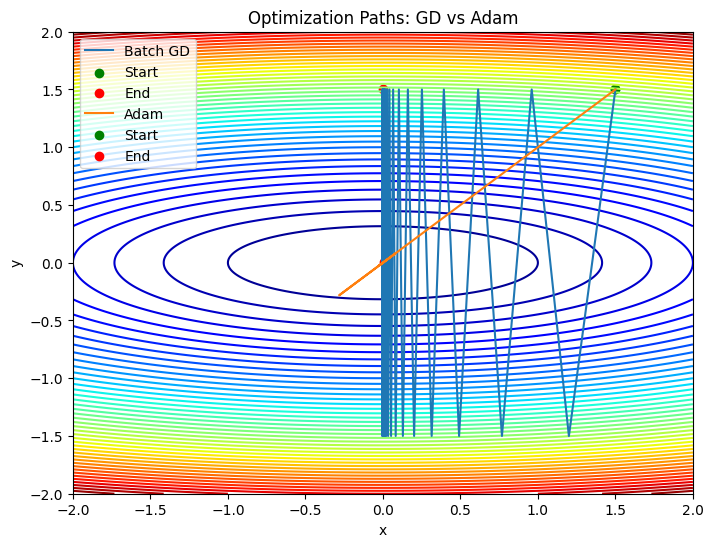

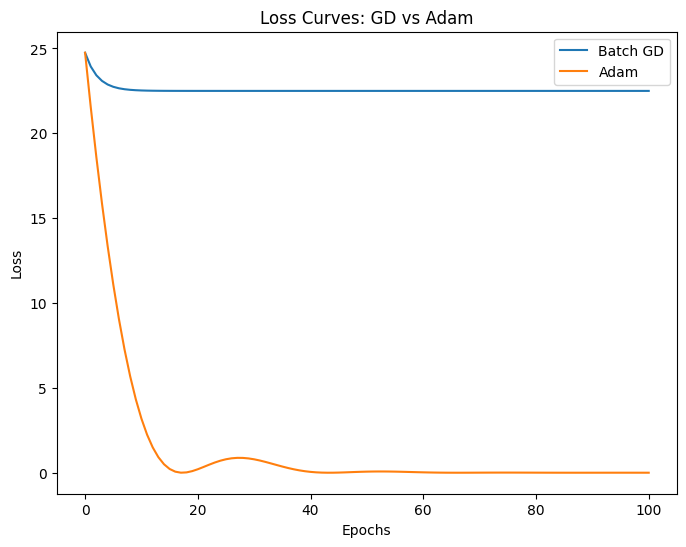

In [10]:
plot_paths(quadratic_loss,[path_gd,path_rmsprop],['Batch GD','Adam'],"Optimization Paths: GD vs Adam")
plot_losses([losses_gd,losses_rmsprop],['Batch GD','Adam'],"Loss Curves: GD vs Adam")